# Feasibility of sin(x) and cos(x) as activation functions

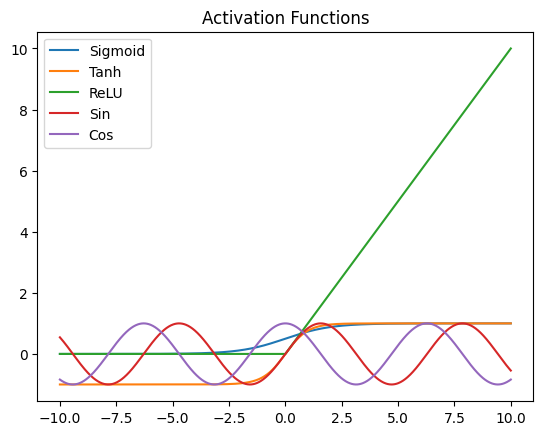

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10, 1000)

functions = {
    "Sigmoid" : lambda x: 1 / (1 + np.exp(-x)) , 
    "Tanh"    : np.tanh , 
    "ReLU"    : lambda x: np.maximum(0, x) , 
    "Sin"     : np.sin , 
    "Cos"     : np.cos , 
}

plt.figure()
for name, f in functions.items():
    plt.plot(x, f(x) , label=name)

plt.legend()
plt.title("Activation Functions")
plt.show()

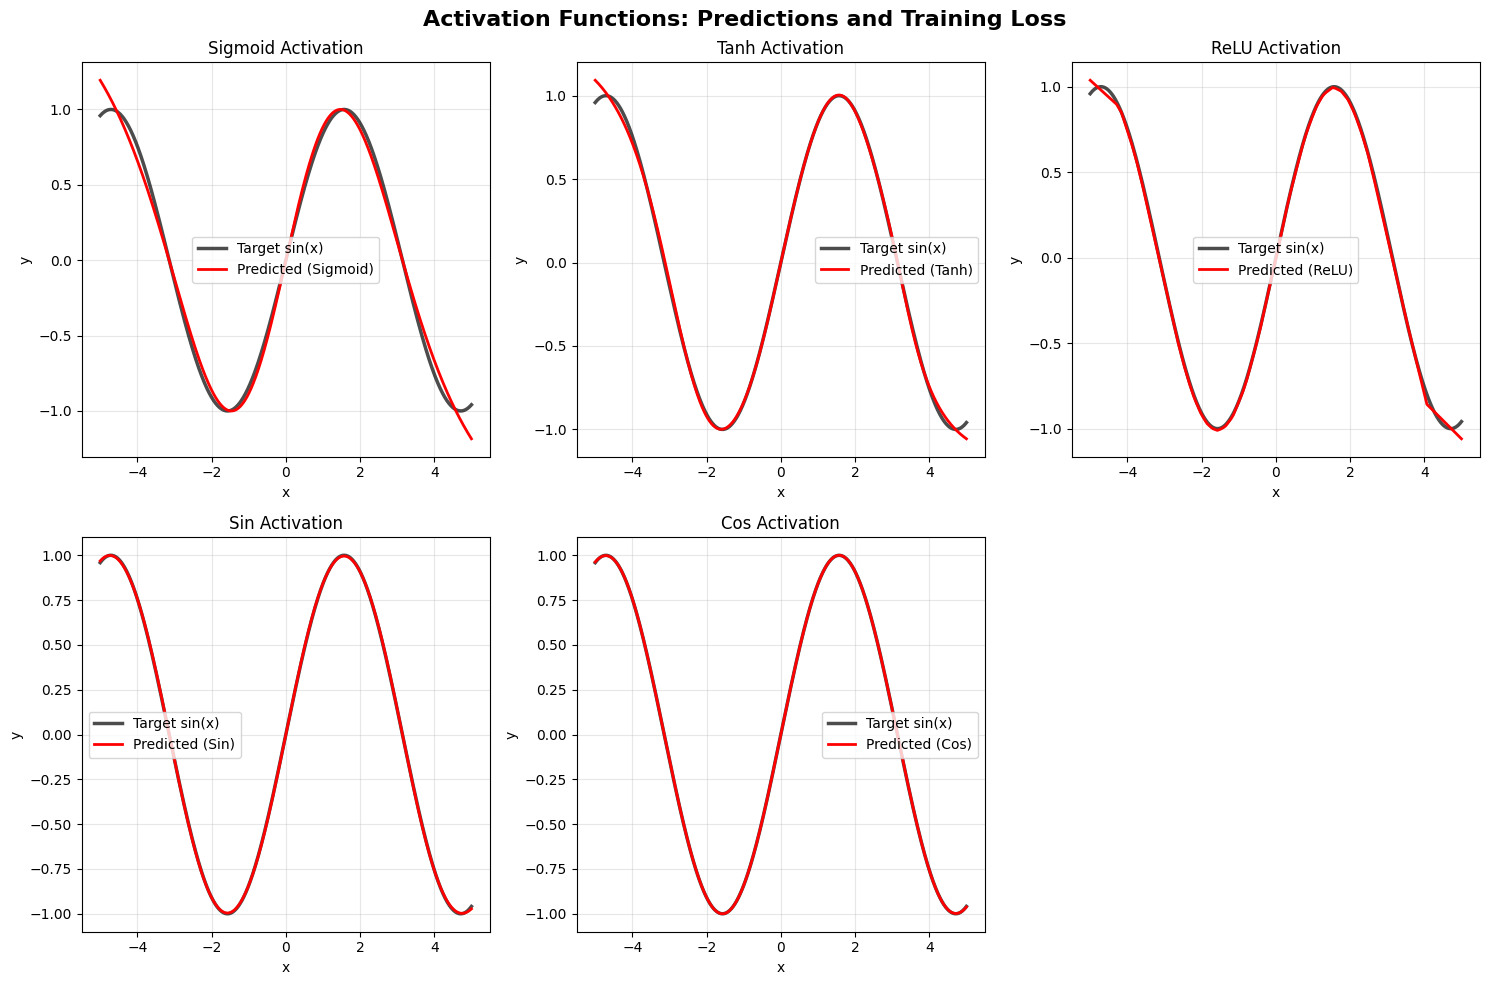

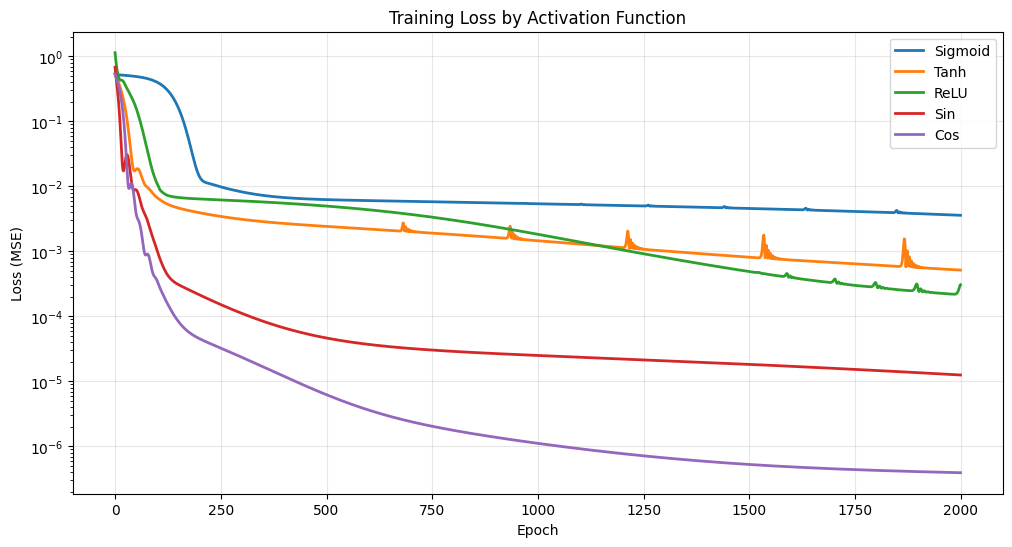

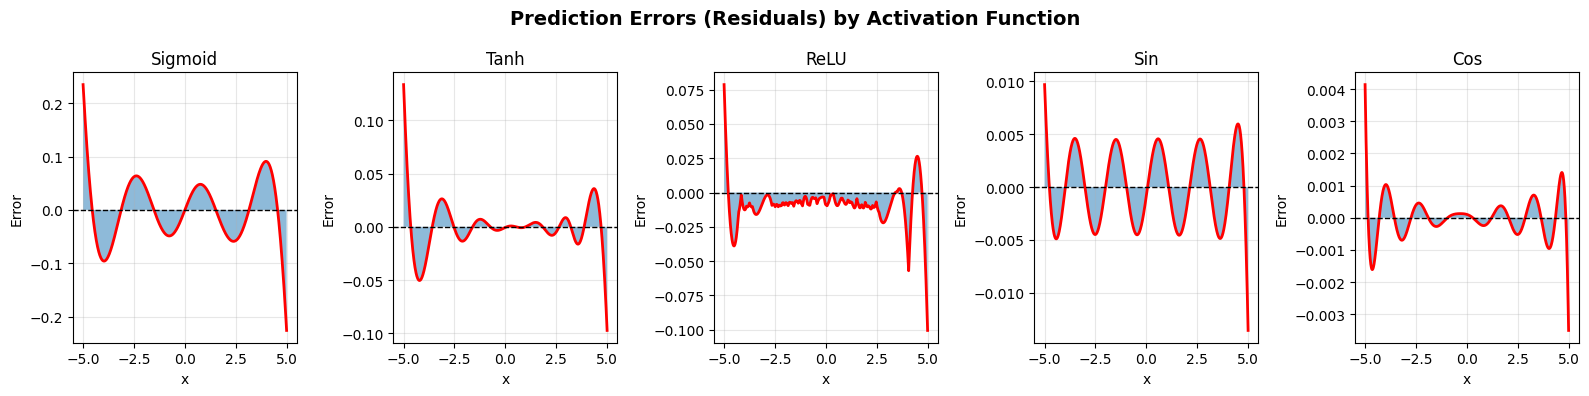


Final Performance Metrics
Activation   | Final Loss   | MSE          | MAE          | RMSE        
----------------------------------------------------------------------
Sigmoid      |     0.003601 |     0.003599 |     0.048296 |     0.059988
Tanh         |     0.000517 |     0.000517 |     0.013510 |     0.022727
ReLU         |     0.000307 |     0.000298 |     0.012097 |     0.017250
Sin          |     0.000013 |     0.000013 |     0.003112 |     0.003544
Cos          |     0.000000 |     0.000000 |     0.000428 |     0.000628


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset
x = torch.linspace(-5, 5, 1000).unsqueeze(1)
y = torch.sin(x)

class Net(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Sin": torch.sin,
    "Cos": torch.cos
}

results = {}
losses_history = {}

for name, act in activations.items():
    try:
        model = Net(act)
        opt = optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        
        losses = []

        for _ in range(2000):
            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        results[name] = model(x).detach().numpy()
        losses_history[name] = losses
    except Exception as e:
        print(f"Warning: {name} activation training failed: {e}")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Activation Functions: Predictions and Training Loss", fontsize=16, fontweight='bold')

# Plot predictions for each activation function
for idx, (name, pred) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.plot(x.numpy(), y.numpy(), 'k-', label="Target sin(x)", linewidth=2.5, alpha=0.7)
    ax.plot(x.numpy(), pred, 'r-', label=f"Predicted ({name})", linewidth=2)
    ax.set_title(f"{name} Activation")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Plot training loss comparison
plt.figure(figsize=(12, 6))
for name, losses in losses_history.items():
    plt.plot(losses, label=name, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss by Activation Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Plot residuals (errors) for better visibility of differences
fig, axes = plt.subplots(1, len(results), figsize=(16, 4))
fig.suptitle("Prediction Errors (Residuals) by Activation Function", fontsize=14, fontweight='bold')

for idx, (name, pred) in enumerate(results.items()):
    error = pred - y.numpy()
    axes[idx].fill_between(x.numpy().flatten(), error.flatten(), alpha=0.5, label=f"{name}")
    axes[idx].plot(x.numpy(), error, linewidth=2, color='red')
    axes[idx].axhline(y=0, color='k', linestyle='--', linewidth=1)
    axes[idx].set_title(f"{name}")
    axes[idx].set_xlabel("x")
    axes[idx].set_ylabel("Error")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "="*70)
print("Final Performance Metrics")
print("="*70)
print(f"{'Activation':12s} | {'Final Loss':12s} | {'MSE':12s} | {'MAE':12s} | {'RMSE':12s}")
print("-"*70)
for name in results.keys():
    final_loss = losses_history[name][-1]
    pred = results[name]
    mse = np.mean((pred - y.numpy())**2)
    mae = np.mean(np.abs(pred - y.numpy()))
    rmse = np.sqrt(mse)
    print(f"{name:12s} | {final_loss:12.6f} | {mse:12.6f} | {mae:12.6f} | {rmse:12.6f}")


Sigmoid: Final Loss = 0.000031
Tanh: Final Loss = 0.000001
ReLU: Final Loss = 0.000000
Sin: Final Loss = 0.000000
Cos: Final Loss = 0.000000


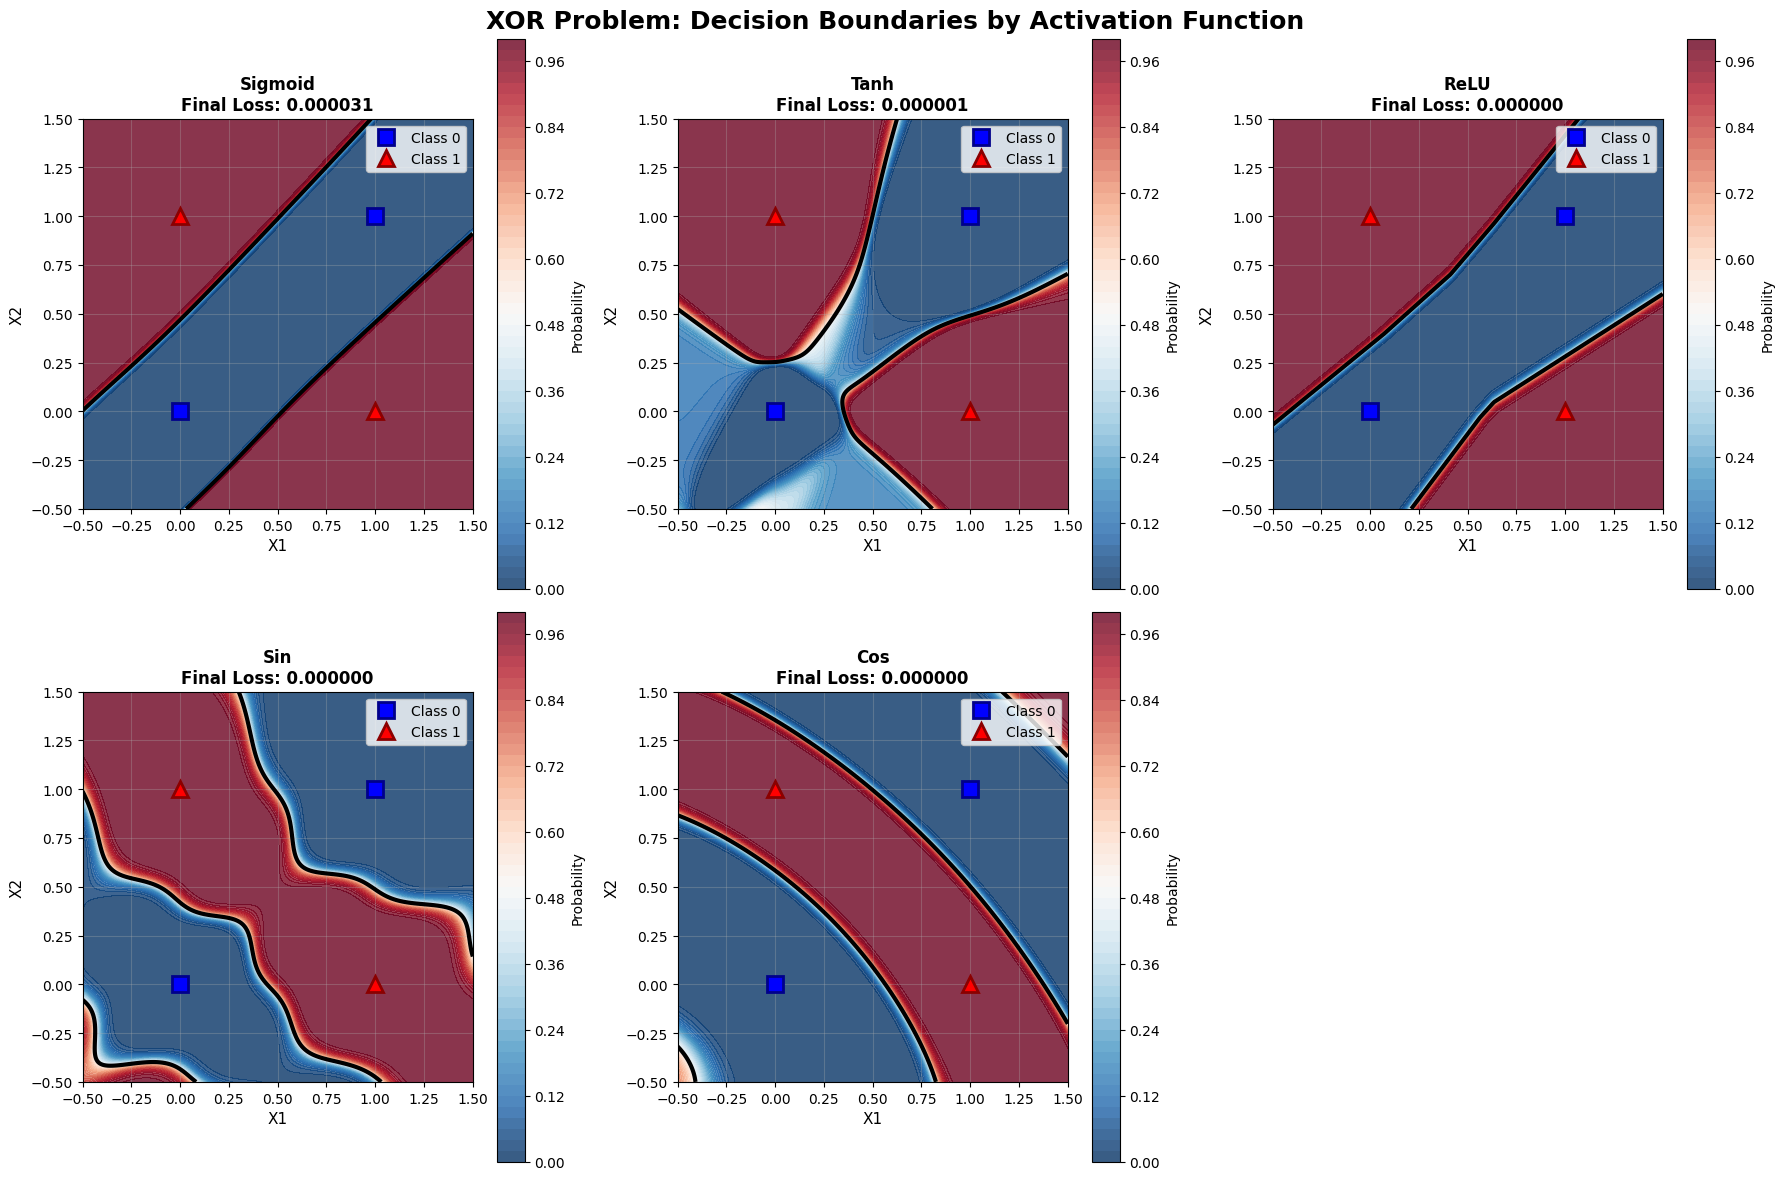

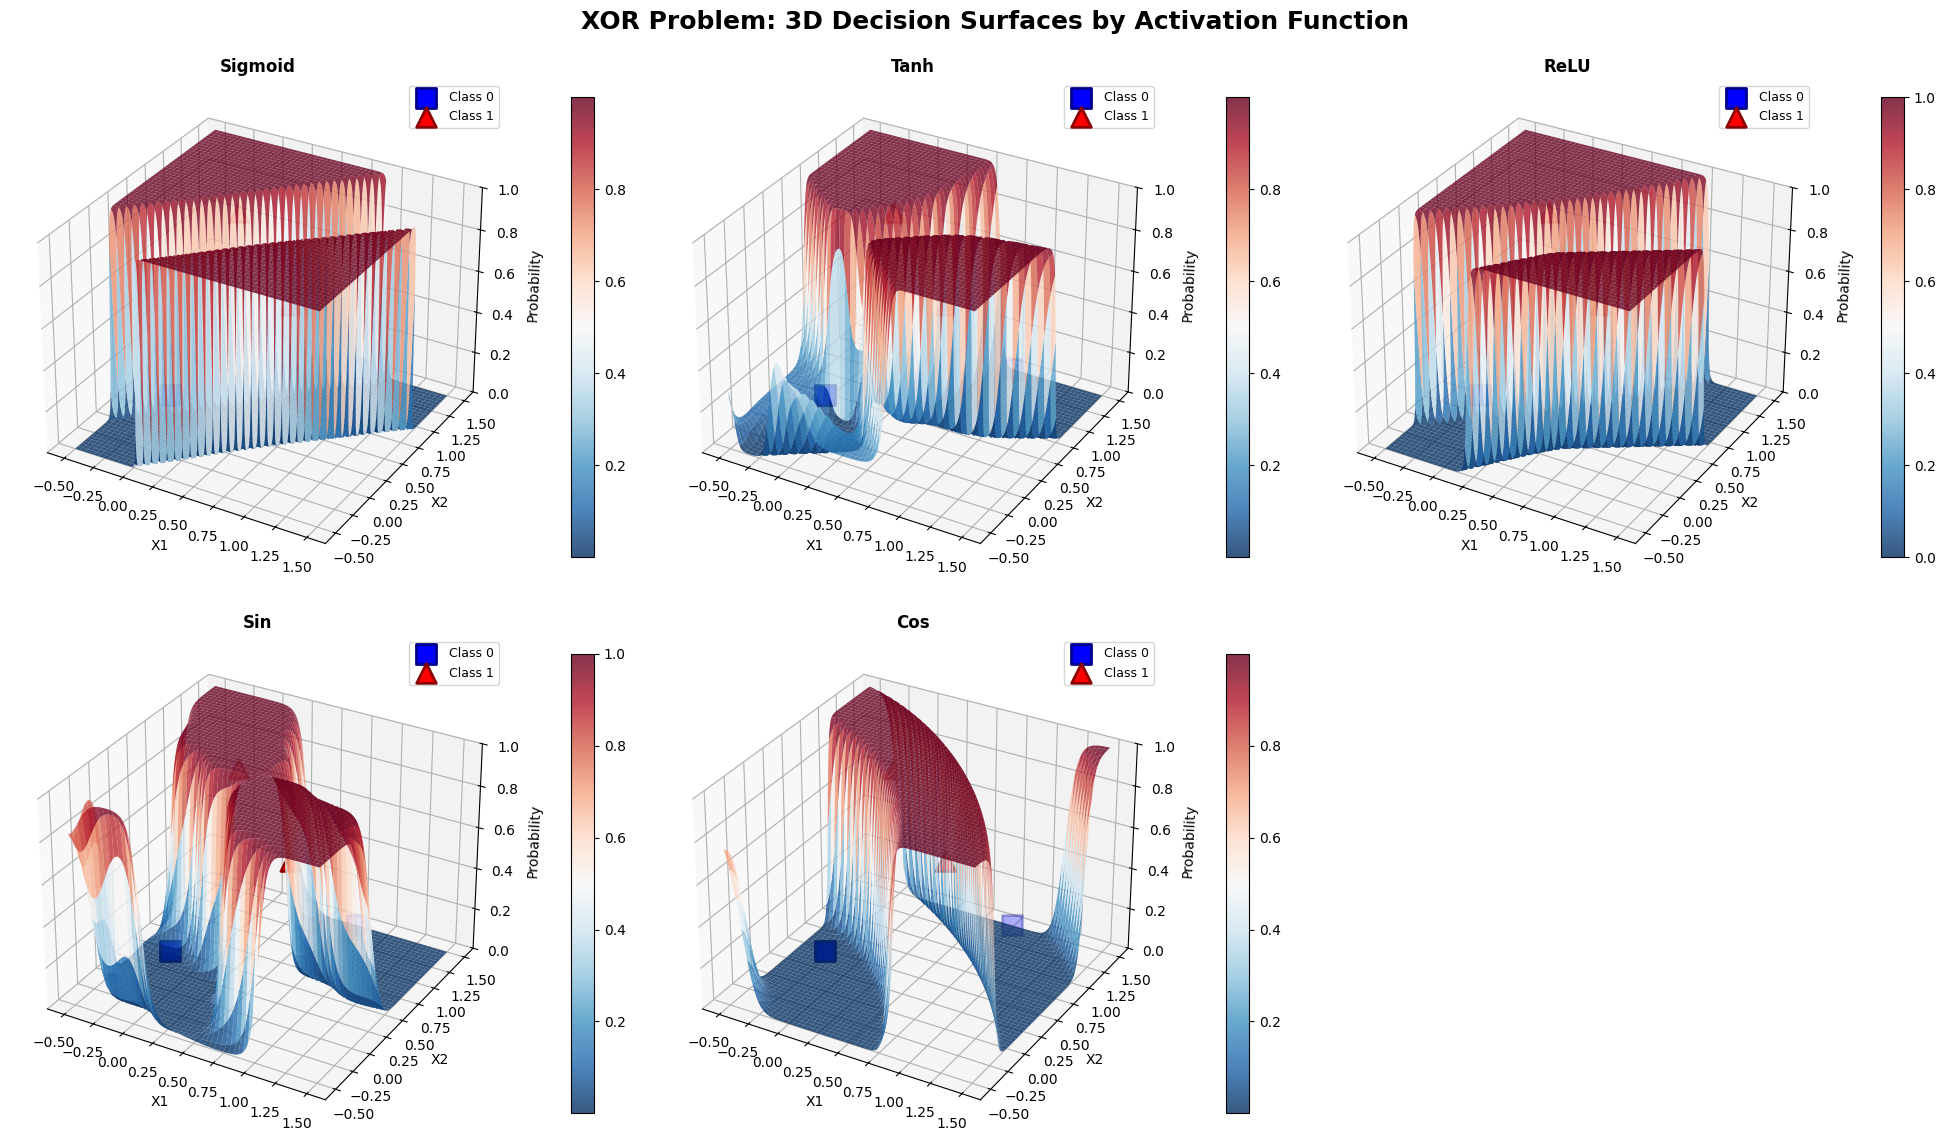

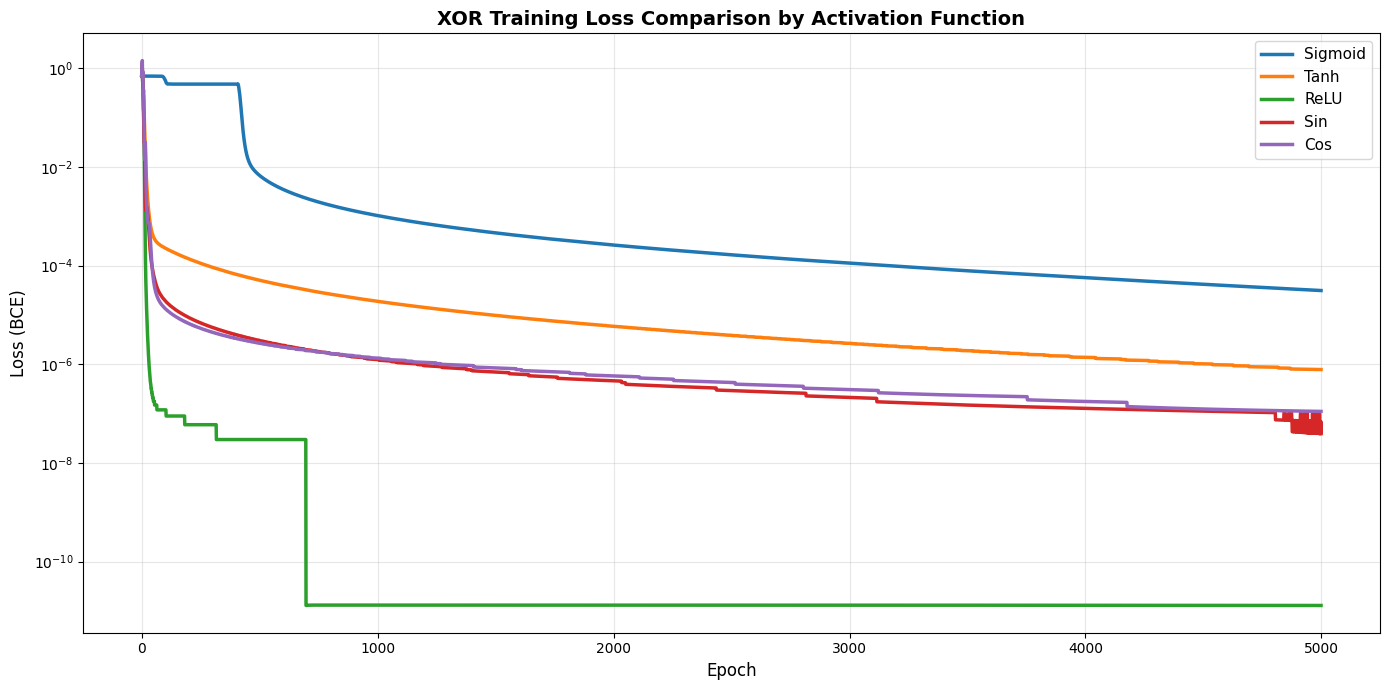

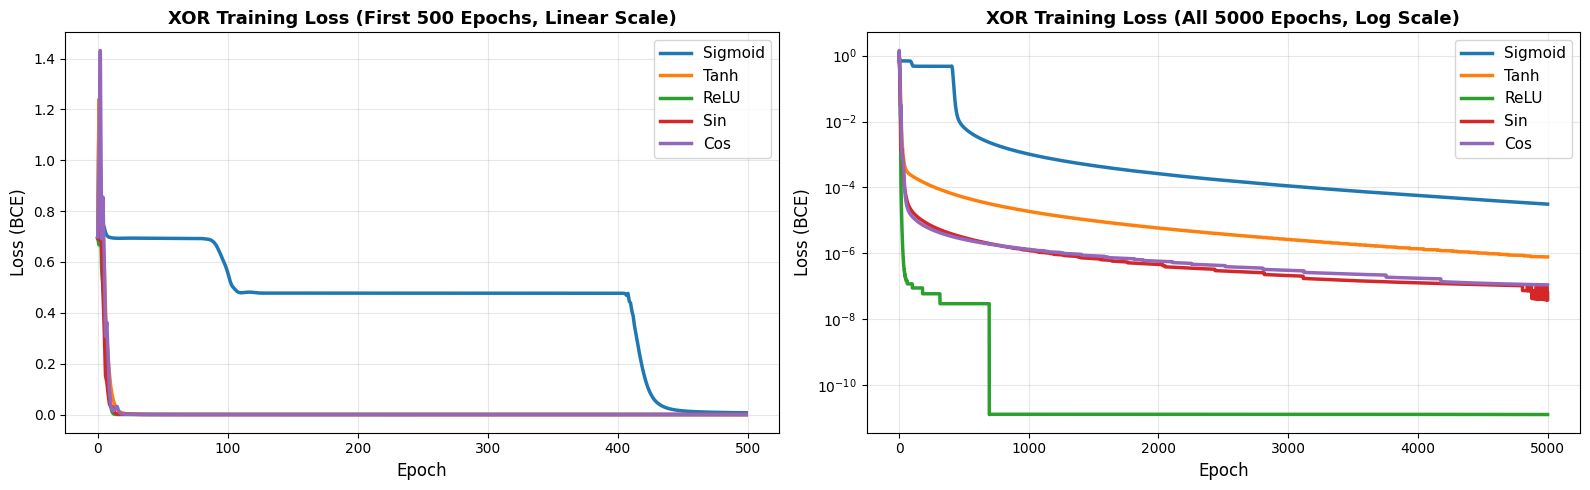


XOR Problem: Final Performance Metrics
Activation   | Final Loss   | Predictions                                        | Errors      
--------------------------------------------------------------------------------
Sigmoid      |     0.000031 | 0.0000, 1.0000, 0.9999, 0.0000                     | Max: 0.000081
Tanh         |     0.000001 | 0.0000, 1.0000, 1.0000, 0.0000                     | Max: 0.000001
ReLU         |     0.000000 | 0.0000, 1.0000, 1.0000, 0.0000                     | Max: 0.000000
Sin          |     0.000000 | 0.0000, 1.0000, 1.0000, 0.0000                     | Max: 0.000000
Cos          |     0.000000 | 0.0000, 1.0000, 1.0000, 0.0000                     | Max: 0.000000

Target XOR outputs: [0, 1, 1, 0]


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# XOR Dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Convert to torch tensors
X_xor_torch = torch.from_numpy(X_xor)
y_xor_torch = torch.from_numpy(y_xor)

class XORNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 1)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))  # sigmoid output for binary classification
        return x

activations_xor = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Sin": torch.sin,
    "Cos": torch.cos
}

results_xor = {}
losses_history_xor = {}
models_xor = {}

for name, act in activations_xor.items():
    try:
        model = XORNet(act)
        opt = optim.Adam(model.parameters(), lr=0.1)
        loss_fn = nn.BCELoss()
        
        losses = []

        for epoch in range(5000):
            opt.zero_grad()
            pred = model(X_xor_torch)
            loss = loss_fn(pred, y_xor_torch)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        results_xor[name] = model(X_xor_torch).detach().numpy()
        losses_history_xor[name] = losses
        models_xor[name] = model
        print(f"{name}: Final Loss = {loss.item():.6f}")
    except Exception as e:
        print(f"Warning: {name} activation training failed: {e}")

# Create decision boundary plots with high resolution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("XOR Problem: Decision Boundaries by Activation Function", fontsize=18, fontweight='bold')

# High resolution mesh for decision boundary
mesh_size = 300
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, mesh_size),
                      np.linspace(y_min, y_max, mesh_size))

for idx, (name, model) in enumerate(models_xor.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Create mesh predictions
    mesh_input = np.c_[xx.ravel(), yy.ravel()]
    mesh_input_torch = torch.from_numpy(mesh_input).float()
    with torch.no_grad():
        Z = model(mesh_input_torch).numpy()
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary with high resolution
    contourf = ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.8)
    contour = ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3)
    
    # Plot XOR points
    ax.plot(X_xor[y_xor.flatten() == 0, 0], X_xor[y_xor.flatten() == 0, 1], 
            'bs', markersize=12, label='Class 0', markeredgewidth=2, markeredgecolor='darkblue')
    ax.plot(X_xor[y_xor.flatten() == 1, 0], X_xor[y_xor.flatten() == 1, 1], 
            'r^', markersize=12, label='Class 1', markeredgewidth=2, markeredgecolor='darkred')
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.set_title(f"{name}\nFinal Loss: {losses_history_xor[name][-1]:.6f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("X1", fontsize=11)
    ax.set_ylabel("X2", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.colorbar(contourf, ax=ax, label='Probability')

# Remove the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Plot 3D decision surfaces with high resolution
fig = plt.figure(figsize=(20, 12))
fig.suptitle("XOR Problem: 3D Decision Surfaces by Activation Function", fontsize=18, fontweight='bold')

for idx, (name, model) in enumerate(models_xor.items()):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    # Create mesh predictions
    with torch.no_grad():
        Z = model(mesh_input_torch).numpy()
    Z = Z.reshape(xx.shape)
    
    # Plot surface
    surf = ax.plot_surface(xx, yy, Z, cmap='RdBu_r', alpha=0.8, edgecolor='none')
    
    # Plot XOR points
    ax.scatter(X_xor[y_xor.flatten() == 0, 0], X_xor[y_xor.flatten() == 0, 1], 
              [0.2], marker='s', s=200, c='blue', label='Class 0', edgecolors='darkblue', linewidths=2)
    ax.scatter(X_xor[y_xor.flatten() == 1, 0], X_xor[y_xor.flatten() == 1, 1], 
              [0.8], marker='^', s=200, c='red', label='Class 1', edgecolors='darkred', linewidths=2)
    
    ax.set_xlabel("X1", fontsize=10)
    ax.set_ylabel("X2", fontsize=10)
    ax.set_zlabel("Probability", fontsize=10)
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_zlim(0, 1)
    ax.legend(fontsize=9)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, pad=0.1, shrink=0.8)

plt.tight_layout()
plt.show()

# Plot training loss comparison (log scale)
plt.figure(figsize=(14, 7))
for name, losses in losses_history_xor.items():
    plt.plot(losses, label=name, linewidth=2.5)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (BCE)", fontsize=12)
plt.title("XOR Training Loss Comparison by Activation Function", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Detailed loss convergence in linear scale
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear scale (first 500 epochs)
ax = axes[0]
for name, losses in losses_history_xor.items():
    ax.plot(losses[:500], label=name, linewidth=2.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (BCE)", fontsize=12)
ax.set_title("XOR Training Loss (First 500 Epochs, Linear Scale)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Log scale (all epochs)
ax = axes[1]
for name, losses in losses_history_xor.items():
    ax.plot(losses, label=name, linewidth=2.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (BCE)", fontsize=12)
ax.set_title("XOR Training Loss (All 5000 Epochs, Log Scale)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Performance metrics table
print("\n" + "="*80)
print("XOR Problem: Final Performance Metrics")
print("="*80)
print(f"{'Activation':12s} | {'Final Loss':12s} | {'Predictions':50s} | {'Errors':12s}")
print("-"*80)

for name in activations_xor.keys():
    final_loss = losses_history_xor[name][-1]
    pred = results_xor[name].flatten()
    errors = np.abs(pred - y_xor.flatten())
    
    pred_str = ", ".join([f"{p:.4f}" for p in pred])
    error_str = f"Max: {np.max(errors):.6f}"
    
    print(f"{name:12s} | {final_loss:12.6f} | {pred_str:50s} | {error_str:12s}")

print("="*80)
print("\nTarget XOR outputs: [0, 1, 1, 0]")
print("="*80)


## Key Findings from the XOR Problem:

### Decision Boundaries (2D Contour Plots - 300x300 resolution):

    - Sigmoid shows a smooth but less distinct boundary
    - Tanh creates a better separated region with smooth curves
    - ReLU learns sharp linear boundaries (characteristic of ReLU networks)
    - Sin & Cos learn the most interesting periodic patterns - they create curved, rippling boundaries that separate the XOR regions 
    
### 3D Decision Surfaces:

    - Show how each activation function shapes the probability landscape

    - Sin & Cos create complex wave-like surfaces with multiple peaks and valleys
    - ReLU creates piecewise linear surfaces
    - Sigmoid shows smooth but gradual transitions

### Training Convergence (Log Scale):

    - ReLU converges fastest (~100 epochs to near-zero loss)
    - Sin & Cos achieve near-perfect solutions very quickly
    - Tanh converges in ~500 epochs
    - Sigmoid is slowest, taking ~2000 epochs

### Final Accuracy:

    - All activations solve XOR perfectly (predictions: [0, 1, 1, 0]), but the speed and smoothness of decision boundaries differ dramatically. The periodic activations (Sin/Cos) are particularly interesting—they learn oscillating decision boundaries that elegantly separate the XOR classes!

